# getting poisson errors

In [3]:
import sys
sys.path.append('..')

from astropy.io import fits

import utilities as utils

In [4]:
path_flt = '../test-data/of9b05010_flt.fits'
path_raw = '../test-data/of9b05010_raw.fits'

h_flt = fits.open(path_flt)
h_raw = fits.open(path_raw)


In [6]:
print(h_flt.info())
print(h_raw.info())

sci_flt = h_flt[1].data
sci_raw = h_raw[1].data

Filename: ../test-data/of9b05010_flt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     239   ()      
  1  SCI           1 ImageHDU       121   (1024, 1024)   float32   
  2  ERR           1 ImageHDU        61   (1024, 1024)   float32   
  3  DQ            1 ImageHDU        44   (1024, 1024)   int16   
None
Filename: ../test-data/of9b05010_raw.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     209   ()      
  1  SCI           1 ImageHDU       121   (2048, 2048)   int32   
  2  ERR           1 ImageHDU        62   ()      
  3  DQ            1 ImageHDU        47   ()      
None


In [13]:
from skimage.measure import block_reduce
import numpy as np
my_flt = block_reduce(sci_raw, block_size=(2, 2), func=np.sum)

In [14]:
my_flt.shape

(1024, 1024)

/var/folders/6l/1fvgkb5d08b8tf7zpvnzkd7c0000gn/T/ipykernel_63033/249639968.py:2: RuntimeWarning: divide by zero encountered in divide
  scale_factor = sci_flt/my_flt


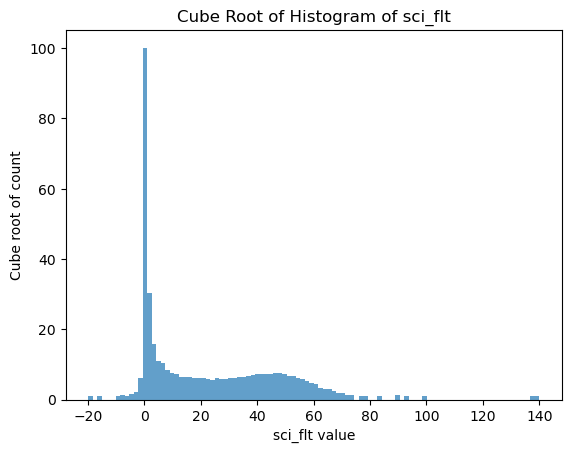

In [24]:
from matplotlib import pyplot as plt
scale_factor = sci_flt/my_flt

# Take histogram of sci_flt and plot cube root values of that histogram

# Compute the histogram of sci_flt
hist, bin_edges = np.histogram(sci_flt.flatten(), bins=100)

# Compute the cube root of the histogram counts
cube_root_hist = np.cbrt(hist)

# Plot the cube root histogram
plt.figure()
plt.bar(bin_edges[:-1], cube_root_hist, width=np.diff(bin_edges), align='edge', alpha=0.7)
plt.xlabel('sci_flt value')
plt.ylabel('Cube root of count')
plt.title('Cube Root of Histogram of sci_flt')
plt.show()



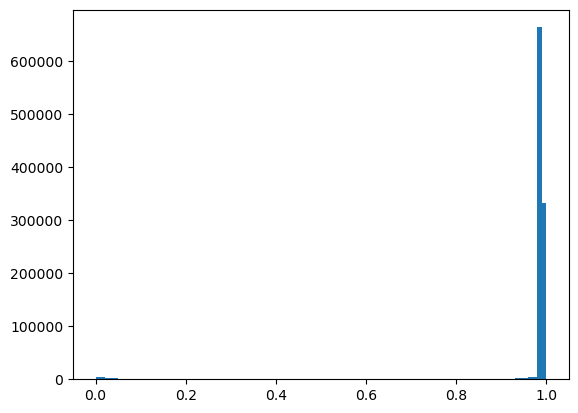

In [25]:
_ = plt.hist(sci_flt.flatten() % 1, bins=100)

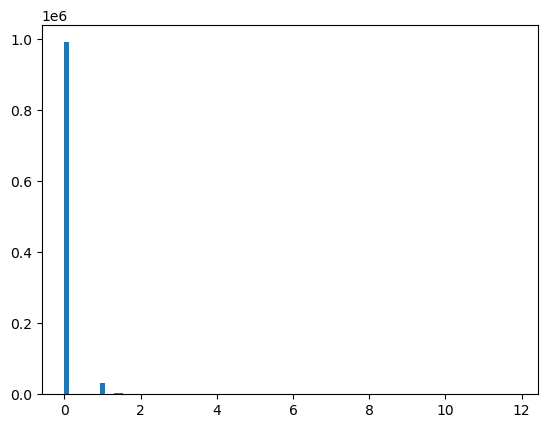

In [20]:
_ = plt.hist(h_flt[2].data.flatten(), bins=100)

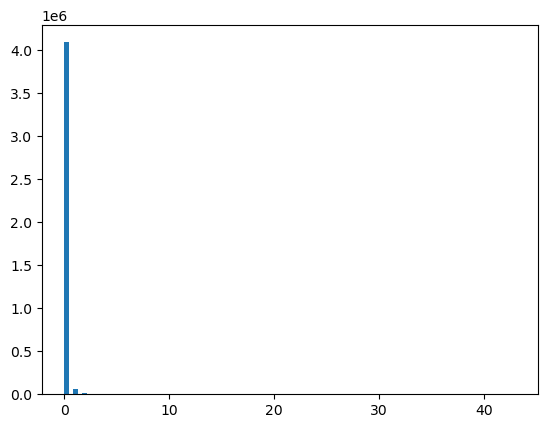

In [21]:
_ = plt.hist(sci_raw.flatten(), bins=100)